In [2]:
import matplotlib.pyplot as plt
import json 
import pandas as pd

In [3]:


df = pd.read_json("my_results_max25kb_with_language.jsonl", lines=True)

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3224 entries, 0 to 3223
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   file      3224 non-null   str   
 1   results   2975 non-null   object
 2   language  340 non-null    str   
dtypes: object(1), str(2)
memory usage: 75.7+ KB


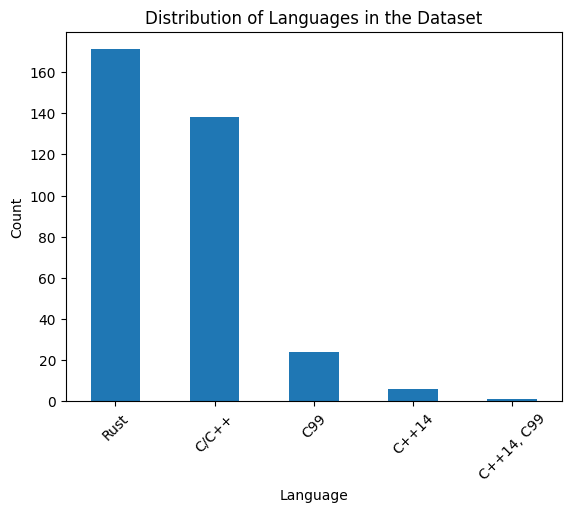

In [ ]:
df["language"].value_counts().plot(kind="bar")
plt.xlabel("Language")
plt.ylabel("Count")
plt.title("Distribution of Languages in the Dataset")
plt.xticks(rotation=45)
plt.savefig("language_distribution.png")
plt.show()

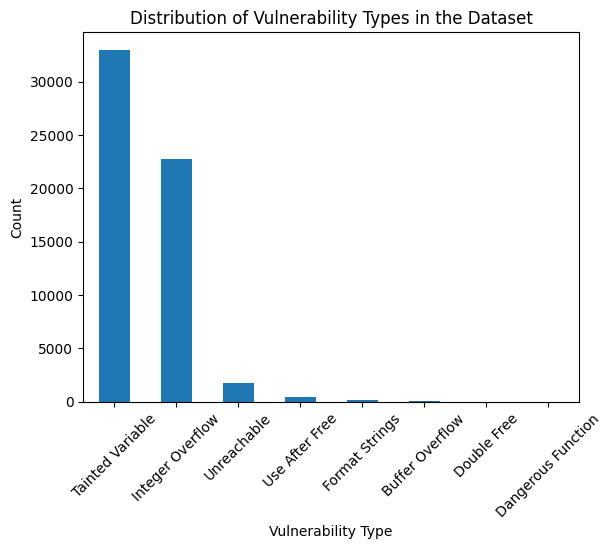

In [ ]:
df = pd.read_json("my_results_max25kb_with_language.jsonl", lines=True)
vulnerabilities = (
    df["results"]
    .dropna()
    .apply(lambda x: x.get("vulnerabilities", []) if isinstance(x, dict) else [])
    .explode()
    .dropna()
    .apply(
        lambda v: (
            v.get("type")
            or v.get("name")
            or v.get("vulnerability")
            or v.get("kind")
            or str(v)
        )
        if isinstance(v, dict)
        else str(v)
    )
    .value_counts()
)
vulnerabilities.plot(kind="bar")
plt.xlabel("Vulnerability Type")
plt.ylabel("Count")
plt.title("Distribution of Vulnerability Types in the Dataset")
plt.xticks(rotation=45)
plt.savefig("vulnerability_distribution.png")
plt.show()  


In [10]:
from collections import Counter

c = Counter()
for vulns in df["results"].dropna():
    for v in vulns.get("vulnerabilities", []):
        c[v.get("type", "UNKNOWN")] += 1

c

Counter({'Tainted Variable': 32998,
         'Integer Overflow': 22708,
         'Unreachable': 1782,
         'Use After Free': 412,
         'Format Strings': 167,
         'Buffer Overflow': 25,
         'Double Free': 8,
         'Dangerous Function': 1})

In [13]:
from collections import Counter, defaultdict
import pandas as pd

df = pd.read_json("my_results_max25kb_with_language.jsonl", lines=True)

counts_by_lang = defaultdict(Counter)

for _, row in df.iterrows():
    lang = row["language"] if pd.notna(row["language"]) else "UNKNOWN"
    results = row["results"]
    vulns = results.get("vulnerabilities", []) if isinstance(results, dict) else []
    for v in vulns:
        vtype = v.get("type", "UNKNOWN")
        counts_by_lang[lang][vtype] += 1

table = pd.DataFrame.from_dict(counts_by_lang, orient="index").fillna(0).astype(int)
table = table.sort_index()

table

,Unreachable,Tainted Variable,Integer Overflow,Use After Free,Format Strings,Double Free,Buffer Overflow,Dangerous Function
C++14,7,0,0,0,0,0,0,0
"C++14, C99",1,0,0,0,0,0,0,0
C/C++,50,190,281,3,119,2,0,0
C99,16,30,45,1,0,1,0,0
Rust,433,117,3773,0,0,0,11,0
UNKNOWN,1275,32661,18609,408,48,5,14,1


,Unreachable,Tainted Variable,Integer Overflow,Use After Free,Format Strings,Double Free,Buffer Overflow,Dangerous Function
count,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,297.000000,5499.666667,3784.666667,68.666667,27.833333,1.333333,4.166667,0.166667
std,507.280199,13306.491719,7411.736441,166.242794,48.614470,1.966384,6.524314,0.408248
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.250000,7.500000,11.250000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,33.000000,73.500000,163.000000,0.500000,0.000000,0.500000,0.000000,0.000000
75%,337.250000,171.750000,2900.000000,2.500000,36.000000,1.750000,8.250000,0.000000
max,1275.000000,32661.000000,18609.000000,408.000000,119.000000,5.000000,14.000000,1.000000


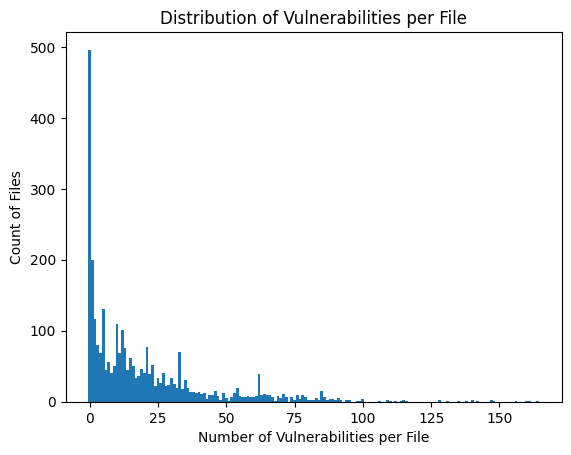

In [ ]:
vuln_counts = df["results"].dropna().apply(lambda x: len(x.get("vulnerabilities", [])) if isinstance(x, dict) else 0)
vuln_counts.describe()
vuln_counts.plot(kind="hist", bins=range(0, vuln_counts.max() + 2), align="left")
plt.xlabel("Number of Vulnerabilities per File")
plt.ylabel("Count of Files")
plt.title("Distribution of Vulnerabilities per File")
plt.savefig("vulnerabilities_per_file_distribution.png")
plt.show()

In [29]:
vuln_counts = df["results"].dropna().apply(lambda x: len(x.get("vulnerabilities", [])) if isinstance(x, dict) else 0)
vuln_counts.describe()


count    2975.000000
mean       19.529748
std        23.631254
min         0.000000
25%         2.000000
50%        12.000000
75%        27.000000
max       164.000000
Name: results, dtype: float64

In [21]:
# 

count    2975.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: results, dtype: float64

In [26]:
import json
import pandas as pd





wanted_types = [
    "Use After Free",
    "Format Strings",
    "Double Free",
    "Buffer Overflow",
    "Dangerous Function",
]

df_wanted = (
    df[["file", "language", "results"]]
    .dropna(subset=["results"])
    .assign(vulnerability=lambda d: d["results"].apply(
        lambda x: x.get("vulnerabilities", []) if isinstance(x, dict) else []
    ))
    .explode("vulnerability")
    .dropna(subset=["vulnerability"])
)

df_wanted["type"] = df_wanted["vulnerability"].apply(
    lambda v: v.get("type") if isinstance(v, dict) else None
)

df_wanted["language"] = df_wanted["language"].fillna("UNKNOWN")
df_wanted = df_wanted[df_wanted["type"].isin(wanted_types)].copy()

count_per_type = (
    df_wanted.groupby("type")["file"]
    .nunique()
    .reindex(wanted_types, fill_value=0)
    .rename("number of files")
    .reset_index()
)

display(count_per_type)

count_type_lang = (
    df_wanted.groupby(["type", "language"])["file"]
    .nunique()
    .reset_index(name="number of files")
)

pivot_type_lang = (
    count_type_lang.pivot(index="type", columns="language", values="number of files")
    .fillna(0)
    .astype(int)
    .reindex(wanted_types, fill_value=0)
)

display(pivot_type_lang)

display(count_type_lang.sort_values(["type", "number of files"], ascending=[True, False]))


,type,number of files
0,Use After Free,327
1,Format Strings,23
2,Double Free,8
3,Buffer Overflow,10
4,Dangerous Function,1


language,C/C++,C99,Rust,UNKNOWN
type,,,,
Use After Free,2,1,0,324
Format Strings,15,0,0,8
Double Free,2,1,0,5
Buffer Overflow,0,0,3,7
Dangerous Function,0,0,0,1


,type,language,number of files
1,Buffer Overflow,UNKNOWN,7
0,Buffer Overflow,Rust,3
2,Dangerous Function,UNKNOWN,1
5,Double Free,UNKNOWN,5
3,Double Free,C/C++,2
4,Double Free,C99,1
6,Format Strings,C/C++,15
7,Format Strings,UNKNOWN,8
10,Use After Free,UNKNOWN,324
8,Use After Free,C/C++,2
